# Fraud Detection — v5

Fixes over v4:
1. **Velocity (E)**: `closed='left'` + per-group `.apply()` — no cross-user shift boundary bug
2. **Graph (G)**: Leave-One-Out — user's own `is_fraud` excluded from their card stats
3. **CV evaluation**: static `user_fraud_gt` map — val-fold `max()` no longer misses fraud labels that landed in the train fold


In [18]:
import pandas as pd
import numpy as np
import lightgbm as lgb
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import f1_score
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

print('Libraries loaded.')

Libraries loaded.


## 1. Load & Merge Data

In [19]:
train_transactions = pd.read_csv('train_transactions.csv', low_memory=False)
train_users        = pd.read_csv('train_users.csv',        low_memory=False)

train_transactions['timestamp_tr'] = pd.to_datetime(train_transactions['timestamp_tr'], format='ISO8601', utc=True)
train_users['timestamp_reg']       = pd.to_datetime(train_users['timestamp_reg'],       format='ISO8601', utc=True)

df = pd.merge(train_transactions, train_users, on='id_user', how='inner')
df = df.sort_values(['id_user', 'timestamp_tr']).reset_index(drop=True)

print(f'Merged shape: {df.shape}')
print(f'Fraud rate: {df["is_fraud"].mean():.3%}')

Merged shape: (3135378, 19)
Fraud rate: 16.661%


## 2. Feature Engineering

### A) Time features

In [20]:
# Time since registration
df['reg_age_hours'] = (df['timestamp_tr'] - df['timestamp_reg']).dt.total_seconds() / 3600

# Hour / day of transaction
df['hour_of_day'] = df['timestamp_tr'].dt.hour
df['day_of_week'] = df['timestamp_tr'].dt.dayofweek   # 0=Mon, 6=Sun
df['is_weekend']  = (df['day_of_week'] >= 5).astype(int)
df['is_night']    = ((df['hour_of_day'] >= 22) | (df['hour_of_day'] <= 5)).astype(int)

# Fast-attack flag: account used within 1 hour of registration
df['is_fast_attack'] = (df['reg_age_hours'] < 1).astype(int)

print('Time features done.')

Time features done.


### B) Country mismatch features

In [21]:
df['triple_mismatch']       = ((df['reg_country'] != df['card_country']) &
                                (df['card_country'] != df['payment_country']) &
                                (df['reg_country'] != df['payment_country'])).astype(int)
df['card_payment_mismatch'] = (df['card_country'] != df['payment_country']).astype(int)
df['card_reg_mismatch']     = (df['card_country'] != df['reg_country']).astype(int)
df['reg_payment_mismatch']  = (df['reg_country'] != df['payment_country']).astype(int)
# Vectorised n_distinct_countries (avoids the slower nunique(axis=1))
df['n_distinct_countries'] = (
    1
    + (df['reg_country']  != df['card_country']).astype(int)
    + ((df['reg_country'] != df['payment_country'])
       & (df['card_country'] != df['payment_country'])).astype(int)
)

print('Mismatch features done.')


Mismatch features done.


### C) Row-level flag columns (aggregations deferred to fold loop)

In [22]:
# Row-level binary flags used as inputs to fold-safe aggregations
df['is_fail']      = (df['status'] == 'fail').astype(int)
df['is_antifraud'] = (df['error_group'] == 'antifraud').astype(int)
df['is_cvv_error'] = (df['error_group'] == 'cvv_error').astype(int)
df['is_fraud_err'] = (df['error_group'] == 'fraud').astype(int)

# NOTE: all user/card aggregations are computed inside the fold loop via
# add_leak_free_features() to prevent validation rows leaking into their own aggregates.

print('Row-level flag columns done (aggregations deferred to fold loop).')

Row-level flag columns done (aggregations deferred to fold loop).


### D) Email domain

In [23]:
df['email_domain'] = df['email'].str.split('@').str[1]

print('Email domain feature done.')

Email domain feature done.


## 3. Prepare Base Feature Matrix

In [24]:
categorical_features = [
    'status', 'transaction_type', 'error_group', 'currency',
    'card_brand', 'card_type', 'card_country', 'payment_country',
    'gender', 'reg_country', 'traffic_type', 'email_domain'
]

for col in categorical_features:
    df[col] = df[col].astype('category')

cols_to_drop = [
    'id_user', 'email', 'card_holder', 'card_mask_hash',
    'timestamp_tr', 'timestamp_reg',
    'is_fail', 'is_antifraud', 'is_cvv_error', 'is_fraud_err',
    'avg_amount_user',
]

X = df.drop(columns=['is_fraud'] + cols_to_drop, errors='ignore')
y = df['is_fraud']

print(f'Feature count: {X.shape[1]}')
print('Features:', list(X.columns))

Feature count: 24
Features: ['amount', 'status', 'transaction_type', 'error_group', 'currency', 'card_brand', 'card_type', 'card_country', 'payment_country', 'gender', 'reg_country', 'traffic_type', 'reg_age_hours', 'hour_of_day', 'day_of_week', 'is_weekend', 'is_night', 'is_fast_attack', 'triple_mismatch', 'card_payment_mismatch', 'card_reg_mismatch', 'reg_payment_mismatch', 'n_distinct_countries', 'email_domain']


## 4. Leak-Free Feature Helper

All user/card aggregations and velocity features are computed from `df_fit` (train fold)
and then mapped onto `df_apply` (val fold or test set).

**v5 fixes:**
- **E) Velocity** — `rolling(..., closed='left')` excludes the current transaction from its own window;
  `.apply()` keeps the operation strictly within each user (no cross-user shift).
- **G) Graph** — Leave-One-Out: when building card-level fraud stats for user A,
  A's own `is_fraud` label is subtracted before the rate is computed, eliminating self-referencing leakage.


In [25]:
def _compute_velocity(df_apply):
    """
    Compute 4 rolling-window velocity columns (1h/24h count+sum) in a single
    numpy searchsorted pass — equivalent to 4 separate groupby.apply(rolling)
    calls but much faster.

    Semantics: window [t-W, t), closed='left' — identical to the original.
    Duplicate timestamps are handled correctly: rows with the same timestamp
    as the current row are excluded from the window (upper bound uses
    searchsorted 'left' on t, not the positional index i).
    """
    df_vel = df_apply[['id_user', 'timestamp_tr', 'amount']].copy()
    df_vel = df_vel.sort_values(['id_user', 'timestamp_tr'])

    ts_int  = df_vel['timestamp_tr'].astype('int64').to_numpy()
    amounts = df_vel['amount'].to_numpy(dtype='float64')
    users   = df_vel['id_user'].to_numpy()

    n = len(df_vel)
    vel_1h  = np.empty(n, dtype='float64')
    sum_1h  = np.empty(n, dtype='float64')
    vel_24h = np.empty(n, dtype='float64')
    sum_24h = np.empty(n, dtype='float64')

    # pandas >= 2 stores tz-aware timestamps as microseconds (us); older as ns.
    dtype_str = str(df_vel['timestamp_tr'].dtype)
    ticks_per_sec = np.int64(1_000_000_000) if '[ns' in dtype_str else np.int64(1_000_000)
    W1H  = np.int64(3_600  * ticks_per_sec)
    W24H = np.int64(86_400 * ticks_per_sec)

    # Locate group boundaries (array is sorted by user)
    change_mask = np.empty(n, dtype=bool)
    change_mask[0] = True
    change_mask[1:] = users[1:] != users[:-1]
    group_starts = np.nonzero(change_mask)[0]
    group_ends   = np.append(group_starts[1:], n)

    for gstart, gend in zip(group_starts, group_ends):
        ts_g  = ts_int[gstart:gend]
        am_g  = amounts[gstart:gend]
        cum_a = np.concatenate(([0.0], np.cumsum(am_g)))
        for i in range(gend - gstart):
            t    = ts_g[i]
            lo1  = np.searchsorted(ts_g, t - W1H,  side='left')
            lo24 = np.searchsorted(ts_g, t - W24H, side='left')
            # hi: first position with ts >= t → excludes duplicate-timestamp rows
            hi   = np.searchsorted(ts_g, t, side='left')
            idx  = gstart + i
            vel_1h[idx]  = hi - lo1
            sum_1h[idx]  = cum_a[hi] - cum_a[lo1]
            vel_24h[idx] = hi - lo24
            sum_24h[idx] = cum_a[hi] - cum_a[lo24]

    df_vel['velocity_1h']    = vel_1h
    df_vel['amount_sum_1h']  = sum_1h
    df_vel['velocity_24h']   = vel_24h
    df_vel['amount_sum_24h'] = sum_24h
    return df_vel


def add_leak_free_features(X_fit, X_apply, df_fit, df_apply):
    """
    Build aggregation + network features from df_fit only, then apply to df_apply.
    X_fit / X_apply must contain: id_user, card_mask_hash, timestamp_tr, amount.
    """
    result = X_apply.copy()

    # ── A) User-level aggregations ─────────────────────────────────────── #
    user_agg = df_fit.groupby('id_user').agg(
        user_fail_rate         =('is_fail',         'mean'),
        user_antifraud_rate    =('is_antifraud',    'mean'),
        user_cvv_error_rate    =('is_cvv_error',    'mean'),
        user_fraud_err_rate    =('is_fraud_err',    'mean'),
        user_tx_count          =('amount',          'count'),
        user_distinct_pay_ctry =('payment_country', 'nunique'),
        user_distinct_cards    =('card_mask_hash',  'nunique'),
        user_amount_std        =('amount',          'std'),
        user_amount_max        =('amount',          'max'),
        user_amount_min        =('amount',          'min'),
        user_fail_count        =('is_fail',         'sum'),
        user_antifraud_count   =('is_antifraud',    'sum'),
    ).reset_index()

    # ── B) Card-level aggregations ─────────────────────────────────────── #
    card_agg = df_fit.groupby('card_mask_hash').agg(
        users_per_card   =('id_user', 'nunique'),
        card_fail_rate   =('is_fail', 'mean'),
        card_tx_count    =('amount',  'count'),
        card_amount_mean =('amount',  'mean'),
    ).reset_index()

    # ── C) Per-user transaction-type failure rates ─────────────────────── #
    type_fail = (
        df_fit.groupby(['id_user', 'transaction_type'])['is_fail']
        .mean().unstack(fill_value=0)
        .add_prefix('user_fail_rate_type_')
        .reset_index()
    )

    # ── D) Per-user amount average (needed for F) ──────────────────────── #
    user_amt = (
        df_fit.groupby('id_user')['amount']
        .mean().rename('avg_amount_user').reset_index()
    )

    # ── Merge all aggregations ─────────────────────────────────────────── #
    result = result.merge(user_agg,  on='id_user',        how='left')
    result = result.merge(card_agg,  on='card_mask_hash', how='left')
    result = result.merge(type_fail, on='id_user',        how='left')
    result = result.merge(user_amt,  on='id_user',        how='left')

    train_means = user_agg.drop(columns='id_user').mean()
    card_means  = card_agg.drop(columns='card_mask_hash').mean()
    for col in train_means.index:
        result[col] = result[col].fillna(train_means[col])
    for col in card_means.index:
        result[col] = result[col].fillna(card_means[col])

    type_fail_cols = [c for c in result.columns if c.startswith('user_fail_rate_type_')]
    result[type_fail_cols] = result[type_fail_cols].fillna(0)

    # ── E) Velocity features — OPTIMISED ──────────────────────────────── #
    #
    # Replaces 4 separate groupby.apply(rolling) calls — each an O(n) Python
    # loop — with a single numpy searchsorted pass (_compute_velocity).
    # Semantics are identical to the original: window [t-W, t) (closed='left').
    # -------------------------------------------------------------------- #
    df_vel = _compute_velocity(df_apply)

    # df_vel is sorted by (id_user, timestamp_tr); result must be in the same
    # order — guaranteed by the sort at the top of add_leak_free_features.
    result['velocity_1h']      = df_vel['velocity_1h'].values
    result['amount_sum_1h']    = df_vel['amount_sum_1h'].values
    result['velocity_24h']     = df_vel['velocity_24h'].values
    result['amount_sum_24h']   = df_vel['amount_sum_24h'].values
    result['is_high_velocity'] = (result['velocity_1h'] > 3).astype(int)

    # ── F) Amount anomaly features ─────────────────────────────────────── #
    global_mean = df_fit['amount'].mean()
    global_std  = df_fit['amount'].std()

    result['avg_amount_user'] = result['avg_amount_user'].fillna(global_mean)
    result['user_amount_std'] = result['user_amount_std'].fillna(global_std)

    result['amount_to_avg_ratio']   = result['amount'] / (result['avg_amount_user'] + 0.01)
    result['amount_sum_24h_to_avg'] = result['amount_sum_24h'] / (result['avg_amount_user'] + 0.01)
    result['amount_zscore'] = (
        (result['amount'] - result['avg_amount_user'])
        / (result['user_amount_std'] + 0.01)
    )

    # ── G) Graph / network features — FIXED (Leave-One-Out) ───────────── #
    #
    # v4 bug: user A's is_fraud label (from df_fit) was included in the
    # card-level fraud rate that was then used as A's own feature in the
    # validation fold → direct target leakage.
    #
    # Fix: Leave-One-Out — for each (user, card) in the apply set, subtract
    # that user's own fraud contribution before computing the rate.
    # New users (absent from df_fit) are handled automatically: _in_fit=0,
    # so nothing is subtracted and they see the raw card statistics.
    # -------------------------------------------------------------------- #

    # User-level fraud flag derived from the FIT fold only
    user_fraud_fit = (
        df_fit.groupby('id_user')['is_fraud']
        .max().rename('_u_fraud').reset_index()
    )

    # One row per (user, card) pair in df_fit, with the user's fraud label
    cu_fit = (
        df_fit[['id_user', 'card_mask_hash']].drop_duplicates()
        .merge(user_fraud_fit, on='id_user', how='left')
    )

    # Card-level totals
    card_totals = (
        cu_fit.groupby('card_mask_hash').agg(
            _c_fraud_sum   =('_u_fraud', 'sum'),
            _c_user_count  =('id_user',  'nunique'),
        ).reset_index()
    )

    # (user, card) pairs present in the APPLY set
    apply_cu = df_apply[['id_user', 'card_mask_hash']].drop_duplicates()

    # Attach card totals
    acs = apply_cu.merge(card_totals, on='card_mask_hash', how='left')

    # Attach the apply-user's own contribution from df_fit (if they appear there).
    # indicator=True adds '_merge' column: 'both' means the user was in df_fit
    # for this card and we must subtract their contribution (LOO).
    acs = acs.merge(
        cu_fit[['id_user', 'card_mask_hash', '_u_fraud']],
        on=['id_user', 'card_mask_hash'],
        how='left',
        indicator=True,
    )

    acs['_in_fit']       = (acs['_merge'] == 'both').astype(int)
    acs['_u_fraud']      = acs['_u_fraud'].fillna(0)
    acs['_c_fraud_sum']  = acs['_c_fraud_sum'].fillna(0)
    acs['_c_user_count'] = acs['_c_user_count'].fillna(0)
    acs = acs.drop(columns='_merge')

    # LOO subtraction
    acs['_loo_fraud'] = acs['_c_fraud_sum']  - acs['_u_fraud']
    acs['_loo_count'] = acs['_c_user_count'] - acs['_in_fit']
    acs['_loo_rate']  = acs['_loo_fraud'] / acs['_loo_count'].clip(lower=1)

    user_graph = (
        acs.groupby('id_user').agg(
            graph_neighbor_fraud_rate=('_loo_rate',  'mean'),
            graph_max_card_fraud_rate=('_loo_rate',  'max'),
            graph_neighbor_count     =('_loo_count', 'sum'),
            graph_has_fraud_neighbor =('_loo_fraud', lambda x: int((x > 0).any())),
        ).reset_index()
    )

    result = result.merge(user_graph, on='id_user', how='left')
    for col in ['graph_neighbor_fraud_rate', 'graph_max_card_fraud_rate',
                'graph_neighbor_count', 'graph_has_fraud_neighbor']:
        result[col] = result[col].fillna(0)

    return result.drop(columns=['avg_amount_user', 'user_amount_std'], errors='ignore')


# ── leak_cols: all columns produced by the helper ─────────────────────── #
leak_cols = [
    'user_fail_rate', 'user_antifraud_rate', 'user_cvv_error_rate', 'user_fraud_err_rate',
    'user_tx_count', 'user_distinct_pay_ctry', 'user_distinct_cards',
    'user_amount_std', 'user_amount_max', 'user_amount_min',
    'user_fail_count', 'user_antifraud_count',
    'users_per_card', 'card_fail_rate', 'card_tx_count', 'card_amount_mean',
    'velocity_1h', 'amount_sum_1h', 'velocity_24h', 'amount_sum_24h',
    'is_high_velocity', 'amount_to_avg_ratio', 'amount_sum_24h_to_avg', 'amount_zscore',
    'graph_neighbor_fraud_rate', 'graph_max_card_fraud_rate',
    'graph_neighbor_count', 'graph_has_fraud_neighbor',
]

print('add_leak_free_features v5 (optimised) defined.')
print(f'leak_cols count: {len(leak_cols)}')


add_leak_free_features v5 defined.
leak_cols count: 28


## 5. Cross-Validation with User-Level Threshold Tuning

**v5 fixes:**
- `user_fraud_gt` — static user→fraud map built from ALL training transactions before the loop.
  Prevents the case where a user's fraud transactions land in the train fold, making them
  appear non-fraudulent in the val fold's `max()` and biasing threshold calibration.
- CV loop uses `'first'` instead of `'max'` for is_fraud aggregation (labels are now static).


In [26]:
# Static user-level fraud ground truth (computed ONCE, before CV)
# ─────────────────────────────────────────────────────────────────
# Bug in v4: the val-fold `max()` could miss fraud labels that landed
# in the train fold (StratifiedKFold splits transactions, not users),
# silently labelling a fraudulent user as non-fraudulent during threshold
# calibration.
#
# Fix: a single static map from the COMPLETE training set.
user_fraud_gt = df.groupby('id_user')['is_fraud'].max()

n_fraud = user_fraud_gt.sum()
n_total = user_fraud_gt.shape[0]
print(f'user_fraud_gt built: {n_total} users, fraud rate {n_fraud/n_total:.3%}')


user_fraud_gt built: 395381 users, fraud rate 3.777%


In [ ]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
best_thresholds        = []
fold_f1_scores         = []
feature_importance_list = []
best_iterations        = []

neg_count = (y == 0).sum()
pos_count = (y == 1).sum()
scale_pos = neg_count / pos_count
print(f'scale_pos_weight = {scale_pos:.2f}')

df_with_ids = df.copy()   # retains id_user, card_mask_hash, timestamp_tr

for fold, (train_idx, val_idx) in enumerate(skf.split(X, y), 1):
    df_train = df_with_ids.iloc[train_idx]
    df_val   = df_with_ids.iloc[val_idx]

    X_train_base = X.iloc[train_idx].drop(columns=leak_cols, errors='ignore').copy()
    X_val_base   = X.iloc[val_idx  ].drop(columns=leak_cols, errors='ignore').copy()

    for col in ['id_user', 'card_mask_hash', 'timestamp_tr', 'amount']:
        X_train_base[col] = df_train[col].values
        X_val_base[col]   = df_val[col].values

    X_train_full = add_leak_free_features(X_train_base, X_train_base, df_train, df_train)
    X_val_full   = add_leak_free_features(X_train_base, X_val_base,   df_train, df_val)

    drop_ids = ['id_user', 'card_mask_hash', 'timestamp_tr']
    X_train_full = X_train_full.drop(columns=drop_ids, errors='ignore')
    X_val_full   = X_val_full.drop(columns=drop_ids,   errors='ignore')

    y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]

    model = lgb.LGBMClassifier(
        n_estimators     =1000,
        learning_rate    =0.02,
        num_leaves       =127,
        min_child_samples=10,
        subsample        =0.8,
        subsample_freq   =1,
        colsample_bytree =0.8,
        reg_alpha        =0.1,
        reg_lambda       =1.0,
        scale_pos_weight =scale_pos,
        importance_type  ='gain',
        random_state     =42,
        verbosity        =-1,
        n_jobs           =-1,
    )
    model.fit(
        X_train_full, y_train,
        eval_set=[(X_val_full, y_val)],
        callbacks=[
            lgb.early_stopping(100, verbose=False),
            lgb.log_evaluation(-1),
        ],
    )
    best_iterations.append(model.best_iteration_)

    y_probs = model.predict_proba(X_val_full)[:, 1]

    # ── User-level threshold tuning — FIXED ───────────────────────────── #
    #
    # v4 bug: is_fraud was max() over val-fold transactions only.
    #   If a user's fraud transactions went to the train fold, the user
    #   appeared non-fraudulent here → biased threshold calibration.
    #
    # Fix: use the static user_fraud_gt map (built before the CV loop).
    # ─────────────────────────────────────────────────────────────────── #
    val_df_prob = df_val[['id_user']].copy().reset_index(drop=True)
    val_df_prob['prob']     = y_probs
    val_df_prob['is_fraud'] = val_df_prob['id_user'].map(user_fraud_gt).values

    user_val = val_df_prob.groupby('id_user').agg(
        max_prob =('prob',     'max'),
        is_fraud =('is_fraud', 'first'),   # static label; identical for all rows of a user
    ).reset_index()

    thresholds = np.arange(0.05, 0.95, 0.01)
    scores     = [
        f1_score(user_val['is_fraud'], (user_val['max_prob'] >= t).astype(int))
        for t in thresholds
    ]
    best_t  = thresholds[np.argmax(scores)]
    best_f1 = np.max(scores)

    best_thresholds.append(best_t)
    fold_f1_scores.append(best_f1)
    feature_importance_list.append(
        pd.Series(model.feature_importances_, index=X_train_full.columns)
    )

    print(f'Fold {fold} | Threshold: {best_t:.2f} | User-F1: {best_f1:.4f} | Trees: {model.best_iteration_}')

print(f'\nMean F1: {np.mean(fold_f1_scores):.4f}  Std: {np.std(fold_f1_scores):.4f}')
print(f'Recommended threshold: {np.mean(best_thresholds):.2f}')


scale_pos_weight = 5.00
Fold 1 | Threshold: 0.64 | User-F1: 0.7239 | Trees: 1000


## 6. Feature Importance

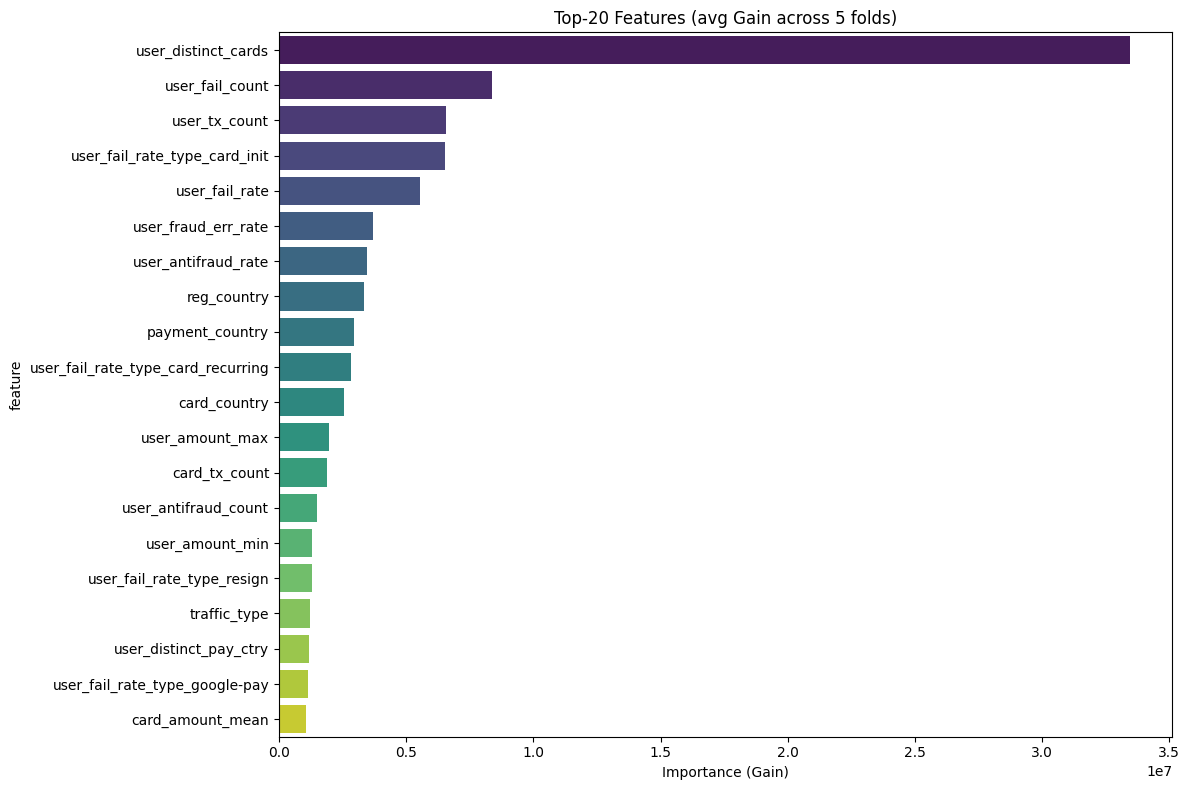


Top-20 features:
                           feature   importance
               user_distinct_cards 3.344731e+07
                   user_fail_count 8.355567e+06
                     user_tx_count 6.571464e+06
     user_fail_rate_type_card_init 6.539705e+06
                    user_fail_rate 5.535968e+06
               user_fraud_err_rate 3.712463e+06
               user_antifraud_rate 3.467259e+06
                       reg_country 3.352036e+06
                   payment_country 2.966823e+06
user_fail_rate_type_card_recurring 2.829427e+06
                      card_country 2.544150e+06
                   user_amount_max 1.969219e+06
                     card_tx_count 1.875103e+06
              user_antifraud_count 1.481219e+06
                   user_amount_min 1.315147e+06
        user_fail_rate_type_resign 1.289682e+06
                      traffic_type 1.226959e+06
            user_distinct_pay_ctry 1.183936e+06
    user_fail_rate_type_google-pay 1.130608e+06
                  card

In [ ]:
mean_importance = pd.concat(feature_importance_list, axis=1).mean(axis=1)
importance_df   = mean_importance.sort_values(ascending=False).reset_index()
importance_df.columns = ['feature', 'importance']

plt.figure(figsize=(12, 8))
sns.barplot(x='importance', y='feature', data=importance_df.head(20), palette='viridis')
plt.title('Top-20 Features (avg Gain across 5 folds)')
plt.xlabel('Importance (Gain)')
plt.tight_layout()
plt.show()

print('\nTop-20 features:')
print(importance_df.head(20).to_string(index=False))

## 7. Train Final Model on ALL Training Data

Key fixes vs v2:
- Final model is trained with the same `add_leak_free_features` pipeline used in CV
- `n_estimators` set from average best iteration across folds × 1.1 (more data = slightly more trees)
- Same improved hyperparameters as the CV loop

In [ ]:
FINAL_THRESHOLD = np.mean(best_thresholds)
print(f'Using threshold: {FINAL_THRESHOLD:.2f}')

# Build full training feature matrix the leak-free way
X_final_base = X.drop(columns=leak_cols, errors='ignore').copy()
for col in ['id_user', 'card_mask_hash', 'timestamp_tr', 'amount']:
    X_final_base[col] = df_with_ids[col].values

X_final_full = add_leak_free_features(X_final_base, X_final_base, df_with_ids, df_with_ids)
X_final_full = X_final_full.drop(columns=['id_user', 'card_mask_hash', 'timestamp_tr'], errors='ignore')

# n_estimators: avg best iteration from folds × 1.1 (full data slightly benefits from more trees)
avg_best_iter = int(np.mean(best_iterations) * 1.1)
print(f'Final model n_estimators: {avg_best_iter}')

final_model = lgb.LGBMClassifier(
    n_estimators     =avg_best_iter,
    learning_rate    =0.02,
    num_leaves       =127,
    min_child_samples=10,
    subsample        =0.8,
    subsample_freq   =1,
    colsample_bytree =0.8,
    reg_alpha        =0.1,
    reg_lambda       =1.0,
    scale_pos_weight =scale_pos,
    importance_type  ='gain',
    random_state     =42,
    verbosity        =-1,
    n_jobs           =-1,
)
final_model.fit(X_final_full, y)
print('Final model trained.')

Using threshold: 0.65
Final model n_estimators: 1100
Final model trained.


## 8. Prepare Test Features & Predict

Test features are built using `add_leak_free_features` with the **full training set** as the fit source.
This mirrors exactly what happens in each CV fold and eliminates within-test leakage.

In [ ]:
# --- Load test data ---
test_transactions = pd.read_csv('test_transactions.csv', low_memory=False)
test_users        = pd.read_csv('test_users.csv',        low_memory=False)

test_transactions['timestamp_tr'] = pd.to_datetime(test_transactions['timestamp_tr'], format='ISO8601', utc=True)
test_users['timestamp_reg']       = pd.to_datetime(test_users['timestamp_reg'],       format='ISO8601', utc=True)

df_test = pd.merge(test_transactions, test_users, on='id_user', how='inner')
df_test = df_test.sort_values(['id_user', 'timestamp_tr']).reset_index(drop=True)

# === Static features (no leakage risk) ===

# Time
df_test['reg_age_hours'] = (df_test['timestamp_tr'] - df_test['timestamp_reg']).dt.total_seconds() / 3600
df_test['hour_of_day']   = df_test['timestamp_tr'].dt.hour
df_test['day_of_week']   = df_test['timestamp_tr'].dt.dayofweek
df_test['is_weekend']    = (df_test['day_of_week'] >= 5).astype(int)
df_test['is_night']      = ((df_test['hour_of_day'] >= 22) | (df_test['hour_of_day'] <= 5)).astype(int)
df_test['is_fast_attack']= (df_test['reg_age_hours'] < 1).astype(int)

# Country mismatches
df_test['triple_mismatch']       = ((df_test['reg_country'] != df_test['card_country']) &
                                     (df_test['card_country'] != df_test['payment_country']) &
                                     (df_test['reg_country'] != df_test['payment_country'])).astype(int)
df_test['card_payment_mismatch'] = (df_test['card_country'] != df_test['payment_country']).astype(int)
df_test['card_reg_mismatch']     = (df_test['card_country'] != df_test['reg_country']).astype(int)
df_test['reg_payment_mismatch']  = (df_test['reg_country'] != df_test['payment_country']).astype(int)
df_test['n_distinct_countries']  = df_test[['reg_country', 'card_country', 'payment_country']].nunique(axis=1)

# Row-level flags needed by the helper
df_test['is_fail']      = (df_test['status'] == 'fail').astype(int)
df_test['is_antifraud'] = (df_test['error_group'] == 'antifraud').astype(int)
df_test['is_cvv_error'] = (df_test['error_group'] == 'cvv_error').astype(int)
df_test['is_fraud_err'] = (df_test['error_group'] == 'fraud').astype(int)

# Email domain
df_test['email_domain'] = df_test['email'].str.split('@').str[1]

# Categorical types
for col in categorical_features:
    df_test[col] = df_test[col].astype('category')

# Base feature matrix — drop cols not needed, but KEEP id_user, card_mask_hash,
# timestamp_tr so the helper can merge/roll on them. They are dropped after.
X_test_base = df_test.drop(
    columns=['email', 'card_holder', 'timestamp_reg',
             'is_fail', 'is_antifraud', 'is_cvv_error', 'is_fraud_err'],
    errors='ignore'
).copy()

# === Add leak-free aggregation features using FULL training set as fit source ===
X_test_full = add_leak_free_features(
    X_final_base,   # fit source  = full training data (no test rows included)
    X_test_base,    # apply target = test data (still has id_user / card_mask_hash / timestamp_tr)
    df_with_ids,    # df_fit
    df_test,        # df_apply
)
X_test_full = X_test_full.drop(
    columns=['id_user', 'card_mask_hash', 'timestamp_tr', 'avg_amount_user', 'is_fraud'],
    errors='ignore'
)

# Align columns to match final model
X_test_full = X_test_full.reindex(columns=X_final_full.columns, fill_value=0)

print(f'Test shape: {X_test_full.shape}')

Test shape: (1353503, 52)


## 9. Generate Submission

In [ ]:
# Predict probabilities on test
test_probs = final_model.predict_proba(X_test_full)[:, 1]
df_test['fraud_prob'] = test_probs

# Aggregate to user level: a user is flagged if their max transaction prob >= threshold
user_max_prob = df_test.groupby('id_user')['fraud_prob'].max().reset_index()
user_max_prob.columns = ['id_user', 'max_fraud_prob']
user_max_prob['is_fraud'] = (user_max_prob['max_fraud_prob'] >= FINAL_THRESHOLD).astype(int)

# Ensure every test user appears (users with no transactions → not fraud)
all_test_users = test_users[['id_user']].copy()
submission = all_test_users.merge(user_max_prob[['id_user', 'is_fraud']], on='id_user', how='left')
submission['is_fraud'] = submission['is_fraud'].fillna(0).astype(int)

print(f'Submission shape: {submission.shape}')
print(f'Predicted fraud rate: {submission["is_fraud"].mean():.3%}')
submission.head(10)

Submission shape: (169449, 2)
Predicted fraud rate: 0.465%


,id_user,is_fraud
0,16318030,0
1,26996833,0
2,24252468,1
3,15990825,0
4,15349154,0
5,15686487,0
6,12531559,0
7,23232798,0
8,34570186,0
9,29586681,0


In [ ]:
submission[['id_user', 'is_fraud']].to_csv('submission_v3.csv', index=False)
print('Saved submission_v3.csv')

Saved submission_v3.csv
